# 增加认知 监听和观察者模式
从头学习整个流程使用规范内容。

In [7]:
from llm_default import getDefaultOPENAI
llm = getDefaultOPENAI()
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

class State(TypedDict):
     # Messages have the type "list". The `add_messages` function
    # 在注释中定义了该状态键应如何更新。
    # （在这种情况下，它将消息附加到列表中，而不是覆盖它们）
    # TODO: state的数据情况是包含list和  存储为增加状态
    messages: Annotated[list, add_messages]
# TODO:「messages 是一个列表（list），并且需要用 add_messages 相关的逻辑来处理这个列表」。
graph_builder = StateGraph(State)

In [8]:
#  添加节点
# 根据历史对话信息，使用大模型生成回复
def chatbot(state : State):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)


In [9]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()

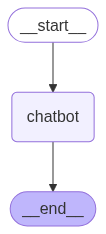

In [10]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # 这需要一些额外的依赖，并且是可选的。
    pass

In [11]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break

        stream_graph_updates(user_input)
    except:
        # 如果 input() 不可用，则备选方案。
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: Hello! How can I assist you today? 😊
Assistant: LangGraph 是一种新兴的技术或框架，主要用于处理语言模型和图结构的结合。它的优势通常体现在以下几个方面：

### 1. **语言模型与图结构的结合**
LangGraph 将语言模型（如 GPT、BERT 等）与图结构结合起来，使得语言理解能力能够与知识图谱或其他图形数据结构相结合。这种结合能够增强模型的推理能力和上下文理解能力，尤其是在复杂关系处理和知识查询场景中。

### 2. **增强推理能力**
通过图结构，LangGraph 可以更好地表示实体之间的关系和上下文信息。这种关系图能够帮助语言模型进行更复杂的推理，例如：
- 多跳推理（跨多个节点的逻辑推导）。
- 处理复杂的因果关系。
- 提供语义关联的更深层次理解。

### 3. **知识整合与查询**
LangGraph 的图结构可以充当知识库的角色，允许语言模型从图中检索信息。这种方式可以显著提高模型的知识覆盖范围，同时减少语言模型对外部知识的依赖。例如：
- 实时查询知识图谱中的数据。
- 动态更新知识库以适应新的信息。

### 4. **可解释性**
传统的语言模型（如 GPT）在生成结果时，通常缺乏可解释性。而通过引入图结构，LangGraph 可以提供更清晰的推理路径和决策依据。例如：
- 通过图节点和边的关系，展示模型如何得出结论。
- 提供可视化的推理过程，帮助用户理解模型行为。

### 5. **多模态支持**
LangGraph 不仅可以处理文本数据，还可以结合其他类型的数据（如图像、视频、传感器数据等）。通过图结构的统一表示，LangGraph 能够支持多模态数据的融合与推理。

### 6. **动态更新与扩展**
传统语言模型通常是静态的，无法轻易更新知识。而 LangGraph 的图结构可以动态更新，允许实时添加新节点和边，从而保持知识的时效性和灵活性。

### 7. **应用场景广泛**
LangGraph 的优势使其在以下场景中表现出色：
- **问答系统**：通过知识图谱增强问答的准确性和深度。
- **推荐系统**：利用图结构的关系推理能力，生成个性化推荐。
- **医学、法律等专业领域**：处理复杂的领域知识和推理需求。
- **数据

In [15]:
print(State["messages"])

__main__.State['messages']
